<a href="https://colab.research.google.com/github/dontasksteven/IS4487/blob/main/Assignments/assignment_4_PetersonSteven.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS4487 Week 4 - Assignment

### Outline

Our Goals with this Project:

1. Import and pre-review the data
2. Examine or profile the data: assess the shape, data types, distributions, missing values or inconsistencies
3. Exploratory data analytics (EDA): create visualizations to better understand the variables and relationships in the data

<a href="https://colab.research.google.com/github/vandanara/UofUtah_IS4487/blob/main/Assignments/assignment_4_data_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### AdviseInvest Data Dictionary

| Variable | Description | Type | Code |
|:---|:---|:---|:---|
| Answered | Customer response | Binary | 0: customer did not answer scheduled call; 1: customer answered scheduled call |
| Income | Customer income in US dollars | Numeric | |
| Female | Customer gender | Binary | 0: female; 1: male |
| Age | Age in years | Numeric | |
| Job | Nature of job | Categorical | 0 : unemployed; 1 : entry level position; 2 : midlevel position; 3 : management/ self-employed/ highly qualified employee/ officer |
| Num_dependents | Number of people for whom the customer provides maintenance | Numeric | |
| Rent | Customer rents | Binary | 0: no; 1: yes |
| Own_res | Customer owns residence | Binary | 0: no; 1: yes |
| New_car | Recent new car purchase | Binary | New car purchase in the last 3 months: 0: no, 1: yes |
| Chk_acct | Checking account status | Categorical | 0 : no checking account; 1: checking < 200 USD; 2 : 200 < checking < 2000 USD; 3: 2000 < checking < 35000 USD; 4: >= 3500 USD |
| Sav_acct | Average balance in savings account | Categorical | 0 : no savings account; 1 : 100 <= savings < 500 USD; 2 : 500 <= savings < 2000 USD; 3 : 2000 < savings < 35000 USD; 4: >= 3500 USD |
| Num_accts | Number of accounts owned by customer | Numeric | |
| Mobile | Mobile phone | Binary | 0: customer provided non‐mobile phone for follow‐up call; 1: customer provided mobile phone for follow‐up call |
| Product | Type of product purchased after conversation with sales rep | Categorical | 0: customer did not answer call; 1: customer answered but did not purchase a product; 2: customer answered and purchased Beginner plan; 3: customer answered and purchased Intermediate plan; 4: customer answered and purchased Advanced plan |


### Load Libraries

Import the libraries you will need, such as:
- Pandas
- Matplotlib
- Seaborn


In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


## Task 1: Import the data and preview it

We are going to import data from the AdviseInvest historical dataset into a dataframe (in GitHub go to the folder called DataSets - click on *'Raw'* button to get the url of raw dataset)

As in the AdviseInvest case, we will assume `answered` is our target variable. Let us a

In [69]:
url= 'https://raw.githubusercontent.com/vandanara/UofUtah_IS4487/refs/heads/main/DataSets/adviseinvest_historical_data.csv'
df=pd.read_csv(url)


## Task 2: Initial Data Understanding: examine or profile the data

 - Profile the dataframe - obtain the shape of the table, data types, counts of variables, missing values
 - Are there any duplicate rows?
 - Describe the dataframe - Look for any outliers



In [70]:
print(df.shape)

(29504, 14)


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29504 entries, 0 to 29503
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   answered        29504 non-null  int64  
 1   income          29504 non-null  int64  
 2   female          29504 non-null  object 
 3   age             29504 non-null  int64  
 4   job             29504 non-null  int64  
 5   num_dependents  29504 non-null  int64  
 6   rent            29504 non-null  int64  
 7   own_res         29504 non-null  int64  
 8   new_car         29502 non-null  float64
 9   chk_acct        29504 non-null  int64  
 10  sav_acct        29504 non-null  int64  
 11  num_accts       29504 non-null  int64  
 12  mobile          29504 non-null  int64  
 13  product         29504 non-null  int64  
dtypes: float64(1), int64(12), object(1)
memory usage: 3.2+ MB


In [72]:
df.head()

,answered,income,female,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
0,1,13520,0,23,0,1,1,0,0.0,0,2,0,1,2
1,0,14780,0,22,2,1,0,1,0.0,3,0,3,0,0
2,1,37570,0,62,2,1,0,0,1.0,3,0,4,0,4
3,0,12450,0,33,2,1,0,1,0.0,1,0,2,0,0
4,0,12400,0,48,1,2,0,0,1.0,2,1,4,0,0


In [73]:
df.isnull().sum()

,0
answered,0
income,0
female,0
age,0
job,0
num_dependents,0
rent,0
own_res,0
new_car,2
chk_acct,0


In [74]:
df.dtypes

,0
answered,int64
income,int64
female,object
age,int64
job,int64
num_dependents,int64
rent,int64
own_res,int64
new_car,float64
chk_acct,int64


In [75]:
print(df.duplicated())


0        False
1        False
2        False
3        False
4        False
         ...  
29499     True
29500     True
29501     True
29502     True
29503     True
Length: 29504, dtype: bool


In [76]:
df[['age', 'num_dependents', 'num_accts']].describe()


,age,num_dependents,num_accts
count,29504.000000,29504.000000,29504.000000
mean,34.773454,1.140998,2.458345
std,11.369865,0.348025,19.497380
min,19.000000,1.000000,0.000000
25%,26.000000,1.000000,2.000000
50%,32.000000,1.000000,2.000000
75%,40.000000,1.000000,3.000000
max,132.000000,2.000000,3345.000000


In [77]:
print(df.describe())


           answered         income           age           job  \
count  29504.000000   29504.000000  29504.000000  29504.000000   
mean       0.546638   33766.893303     34.773454      1.915401   
std        0.497829   29379.202710     11.369865      0.658183   
min        0.000000  -65600.000000     19.000000      0.000000   
25%        0.000000   13550.000000     26.000000      2.000000   
50%        1.000000   23310.000000     32.000000      2.000000   
75%        1.000000   41690.000000     40.000000      2.000000   
max        1.000000  159450.000000    132.000000      3.000000   

       num_dependents          rent       own_res       new_car      chk_acct  \
count    29504.000000  29504.000000  29504.000000  29502.000000  29504.000000   
mean         1.140998      0.210412      0.681128      0.240797      1.468547   
std          0.348025      0.407608      0.466047      0.427575      1.234727   
min          1.000000      0.000000      0.000000      0.000000      0.000000   


In [78]:
q_low = df['num_accts'].quantile(0.01)
q_high  = df['num_accts'].quantile(0.99)
df = df[(df['num_accts'] >= q_low) & (df['num_accts'] <= q_high)]

In [79]:
q_low = df['age'].quantile(0.01)
q_high  = df['age'].quantile(0.99)
df = df[(df['age'] >= q_low) & (df['age'] <= q_high)]

In [80]:
print(df.describe())

           answered         income           age           job  \
count  29181.000000   29181.000000  29181.000000  29181.000000   
mean       0.546040   33725.364107     34.588534      1.914533   
std        0.497884   29443.326456     10.943093      0.655050   
min        0.000000  -65600.000000     20.000000      0.000000   
25%        0.000000   13520.000000     26.000000      2.000000   
50%        1.000000   23260.000000     32.000000      2.000000   
75%        1.000000   41100.000000     40.000000      2.000000   
max        1.000000  159450.000000     68.000000      3.000000   

       num_dependents          rent       own_res       new_car      chk_acct  \
count    29181.000000  29181.000000  29181.000000  29179.000000  29181.000000   
mean         1.140331      0.208355      0.686371      0.241235      1.464823   
std          0.347336      0.406139      0.463975      0.427840      1.236734   
min          1.000000      0.000000      0.000000      0.000000      0.000000   


## Task 3: Explore the data - create visualizations
- Explore the relationships between the target and independent variables
- Create at least five charts to show the relationships, using different chart types that are approriate to the analysis
- Ensure that all charts are clearly labeled and formatted

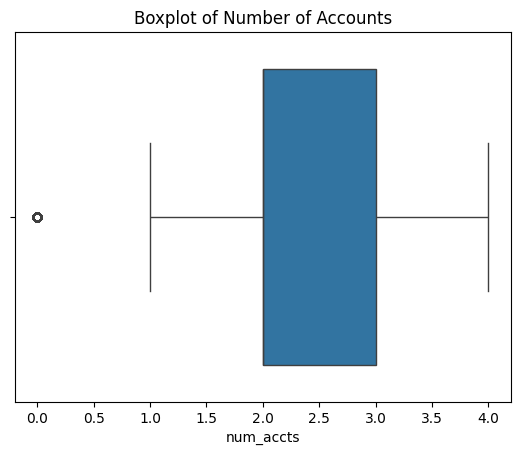

In [81]:
sns.boxplot(x=df['num_accts'])
plt.title("Boxplot of Number of Accounts")
plt.show()

<Axes: title={'center': 'Distribution of Age'}, ylabel='Frequency'>

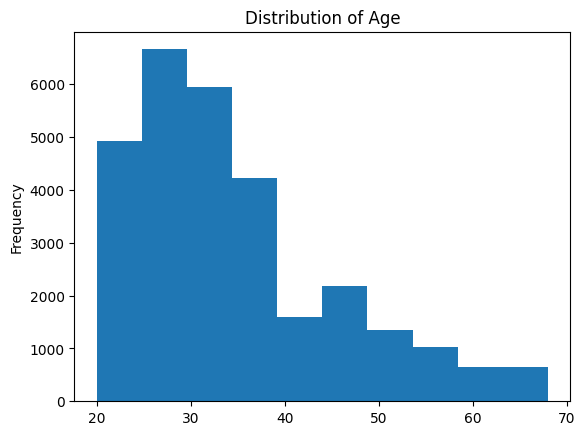

In [82]:
df['age'].plot(kind='hist', bins=10, title='Distribution of Age')

<Axes: title={'center': 'Number of Dependents'}, ylabel='count'>

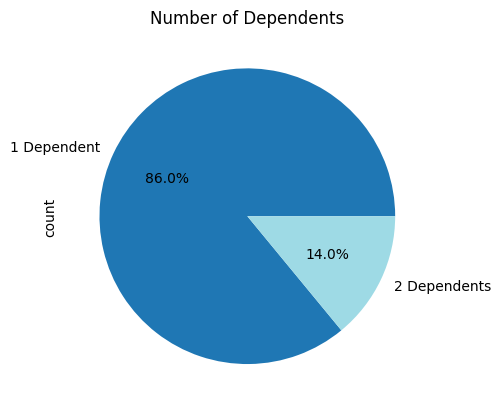

In [83]:
dependents_counts = df['num_dependents'].value_counts()
dependents_counts.plot(kind='pie', autopct='%1.1f%%', labels=['1 Dependent', '2 Dependents'], title='Number of Dependents', colormap="tab20")

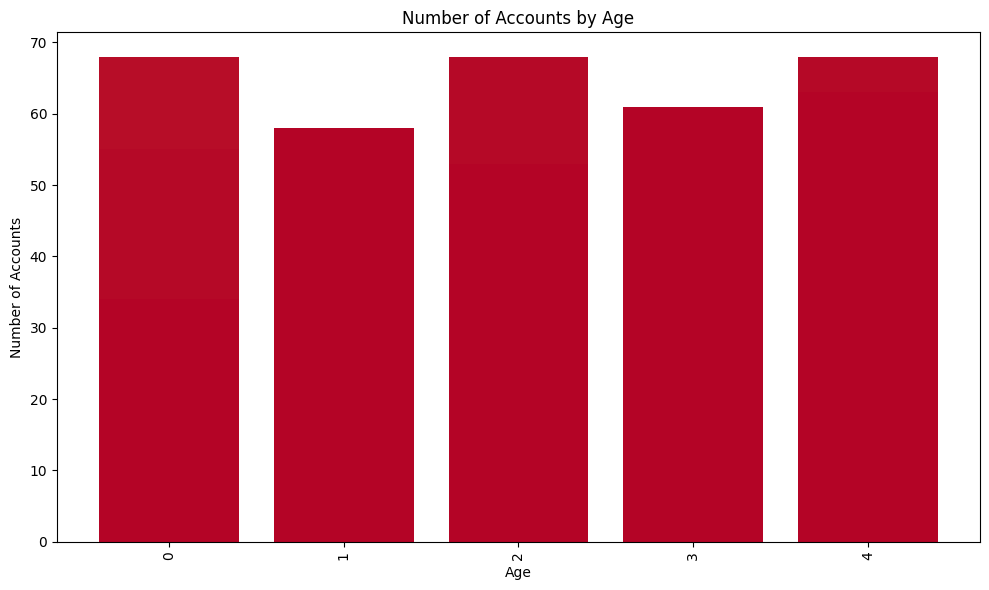

In [100]:
plt.figure(figsize=(10, 6))
plt.bar(df['num_accts'], df['age'], color=plt.cm.coolwarm(np.linspace(0, 1, len(df))))
plt.title("Number of Accounts by Age")
plt.xlabel("Age")
plt.ylabel("Number of Accounts")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

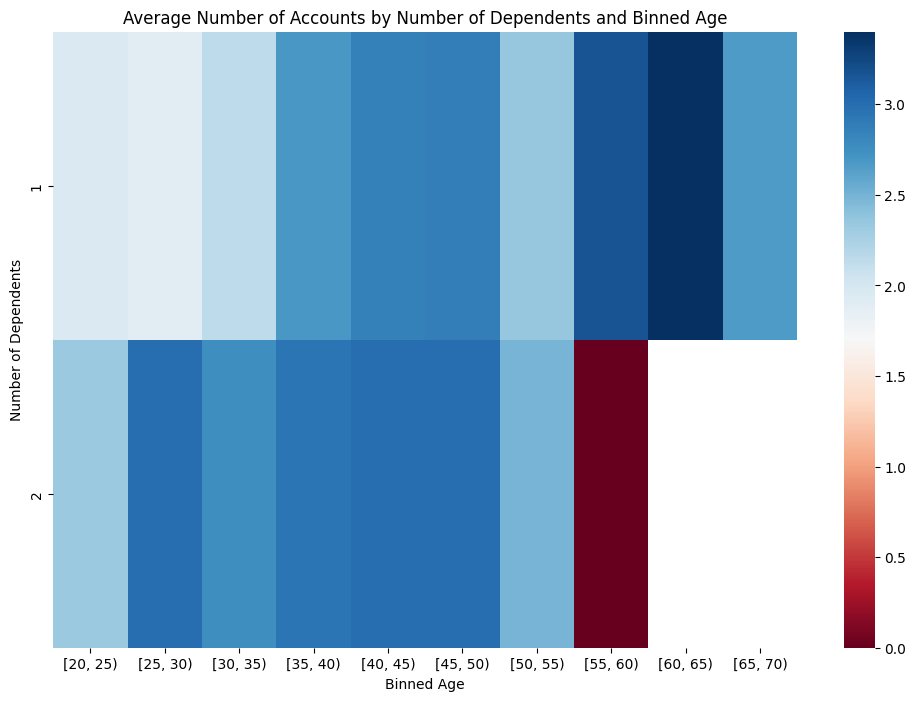

In [124]:
# Create bins of 5 for the 'age' column
df['age_binned'] = pd.cut(df['age'], bins=range(df['age'].min(), df['age'].max() + 6, 5), right=False)

# Prepare data for the heatmap: Group by num_dependents and age_binned, then calculate the mean of num_accts
heatmap_data = df.groupby(['num_dependents', 'age_binned'], observed=True)['num_accts'].mean().unstack()

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=False, cmap='RdBu')
plt.title('Average Number of Accounts by Number of Dependents and Binned Age')
plt.xlabel('Binned Age')
plt.ylabel('Number of Dependents')
plt.show()

## Task 4: Summarize Your Findings
### 4.1: Are all of the variables useful and applicable to the business need?  (you should reference the target variable and whether other variables have are likely to be correlated with the target)

Write your response below:  🔧

Many of the data types provided can feel a bit useless. As important as the Binary data types are things such as gender won't play a role into whether the customer picks up the phone or not. Dispite this binary variables such as Mobile and Answered can play a huge role potentially into finding out how the company can increase caller retention.

### 4.2: In what ways could the dataset be improved?  Are there any data quality issues or data types that should be fixed?

Write your response below: 🔧

One thing that I can see how the dataset could be improved is in the chk_acct and sav_acct variables. Rather than these variables being categorical it could potentially be beneficial to look at these numerically. Rather than bins being established we could see if there is a certain "threshold" where people may be more likely to purchase the product or more valuable products.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas

In [134]:
!jupyter nbconvert --to html "assignment_4_PetersonSteven.ipynb"

[NbConvertApp] Converting notebook assignment_4_PetersonSteven.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 459016 bytes to assignment_4_PetersonSteven.html
